In [ ]:

import pandas as pd
import nltk
from nltk.corpus import stopwords
import string
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline


df = pd.read_csv(url)

print("Dataset Loaded Successfully!")
print("Dataset Shape:", df.shape)
print("\nArticle counts per category:")
print(df['category'].value_counts())

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_article(text):
    text = text.lower() 
    text = text.translate(str.maketrans('', '', string.punctuation)) # Remove punctuation
    words = text.split()
    cleaned_words = [word for word in words if word not in stop_words] # Remove stopwords
    return " ".join(cleaned_words)


df['text_cleaned'] = df['text'].apply(clean_article)


X_train, X_test, y_train, y_test = train_test_split(
    df['text_cleaned'],
    df['category'],
    test_size=0.2,
    random_state=42,
    stratify=df['category']
)

model = make_pipeline(TfidfVectorizer(), MultinomialNB())

# Train the model
model.fit(X_train, y_train)
print("\nModel trained successfully on the BBC news archive!")

Dataset Loaded Successfully!
Dataset Shape: (2225, 2)

Article counts per category:
category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.



Model trained successfully on the BBC news archive!


--- Testing Automated Classification ---
Article: 'The striker scored a stunning hat-trick in the final minutes to win the championship match.'
👉 Predicted Category: SPORT

Article: 'Shares of the tech giant plummeted after the government announced strict new antitrust regulations.'
👉 Predicted Category: BUSINESS

Article: 'The new sci-fi movie broke box office records on its opening weekend, receiving glowing reviews from critics.'
👉 Predicted Category: ENTERTAINMENT

--- Overall Model Evaluation ---
Total Model Accuracy: 98.43%

Detailed Performance Matrix:
               precision    recall  f1-score   support

     business       0.98      0.98      0.98       102
entertainment       1.00      0.96      0.98        77
     politics       0.94      1.00      0.97        84
        sport       1.00      1.00      1.00       102
         tech       1.00      0.97      0.99        80

     accuracy                           0.98       445
    macro avg       0.98      0.98      0.98   

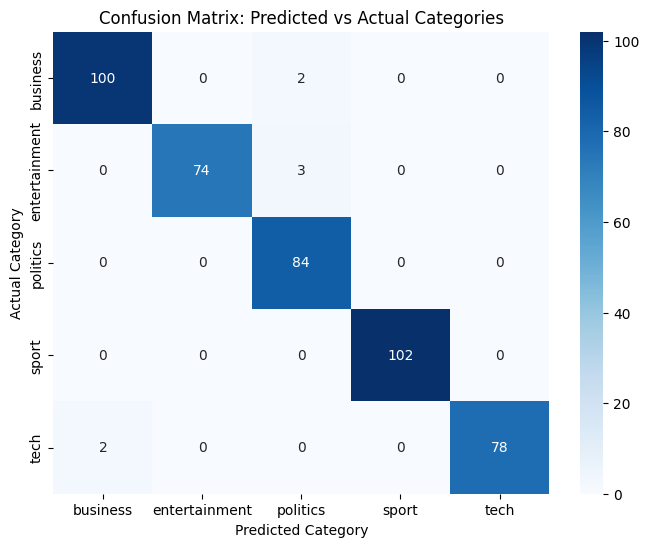

In [ ]:

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


mock_articles = [
    "The striker scored a stunning hat-trick in the final minutes to win the championship match.",
    "Shares of the tech giant plummeted after the government announced strict new antitrust regulations.",
    "The new sci-fi movie broke box office records on its opening weekend, receiving glowing reviews from critics."
]

print("--- Testing Automated Classification ---")
for article in mock_articles:
    
    cleaned_art = clean_article(article)
  
    prediction = model.predict([cleaned_art])[0]
    print(f"Article: '{article}'")
    print(f" Predicted Category: {prediction.upper()}\n")



y_pred = model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
print("--- Overall Model Evaluation ---")
print(f"Total Model Accuracy: {accuracy * 100:.2f}%\n")

print("Detailed Performance Matrix:")
print(classification_report(y_test, y_pred))


cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Confusion Matrix: Predicted vs Actual Categories')
plt.xlabel('Predicted Category')
plt.ylabel('Actual Category')
plt.show()